In [1]:
import pandas as pd

df = pd.read_csv("df_model_hazır3.csv")

print(df.columns)
print(df["Severity_num"].value_counts())


Index(['Latitude', 'Longitude', 'Number_of_Casualties', 'Number_of_Vehicles',
       'Speed_limit', 'Urban_or_Rural_Area', 'Year', 'Month', 'Day', 'Weekday',
       'Hour', 'Is_Rush_Hour', 'Is_Weekend', 'Is_Night', 'Bad_Road_Condition',
       'Bad_Weather', 'Day_Monday', 'Day_Saturday', 'Day_Sunday',
       'Day_Thursday', 'Day_Tuesday', 'Day_Wednesday', 'Season_Spring',
       'Season_Summer', 'Season_Winter', 'Road_Type_One way street',
       'Road_Type_Roundabout', 'Road_Type_Single carriageway',
       'Road_Type_Slip road', 'Vehicle_Group_Goods',
       'Vehicle_Group_Motorcycle', 'Vehicle_Group_Other',
       'Vehicle_Group_Public', 'Vehicle_Group_Vulnerable',
       'Junction_Control_Grouped_No_Junction',
       'Junction_Control_Grouped_Sign_Controlled',
       'Junction_Control_Grouped_Unknown',
       'Junction_Detail_Grouped_No_Junction',
       'Junction_Detail_Grouped_Roundabout',
       'Junction_Detail_Grouped_Simple_Junction', 'Severity_num',
       'Speed_Category_Me

In [2]:
from sklearn.model_selection import train_test_split

TARGET = "Severity_num"   # hedef sütun

# X-y ayır
X = df.drop(columns=[TARGET]).copy()
y = df[TARGET].astype(int).copy()

# stratify: sınıf dağılımını train/test'te korur (çok önemli!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("\ny_train dağılım:\n", y_train.value_counts())
print("\ny_test dağılım:\n", y_test.value_counts())


X_train: (246378, 42) X_test: (61595, 42)

y_train dağılım:
 Severity_num
0    210624
1     32592
2      3162
Name: count, dtype: int64

y_test dağılım:
 Severity_num
0    52656
1     8148
2      791
Name: count, dtype: int64


In [3]:
##Model 1: Random Forest (Imbalanced Data)

In [4]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [5]:
y_pred = rf_model.predict(X_test)

In [6]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      1.00      0.92     52656
           1       0.35      0.01      0.02      8148
           2       0.40      0.00      0.01       791

    accuracy                           0.85     61595
   macro avg       0.54      0.34      0.31     61595
weighted avg       0.78      0.85      0.79     61595



In [7]:
##Model 2: Random Forest (Balanced Training Set)

In [8]:
from sklearn.ensemble import RandomForestClassifier

rf_balanced = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_balanced.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [9]:
y_pred_bal = rf_balanced.predict(X_test)

In [10]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_bal))

              precision    recall  f1-score   support

           0       0.86      1.00      0.92     52656
           1       0.32      0.00      0.01      8148
           2       0.33      0.00      0.00       791

    accuracy                           0.85     61595
   macro avg       0.50      0.33      0.31     61595
weighted avg       0.78      0.85      0.79     61595



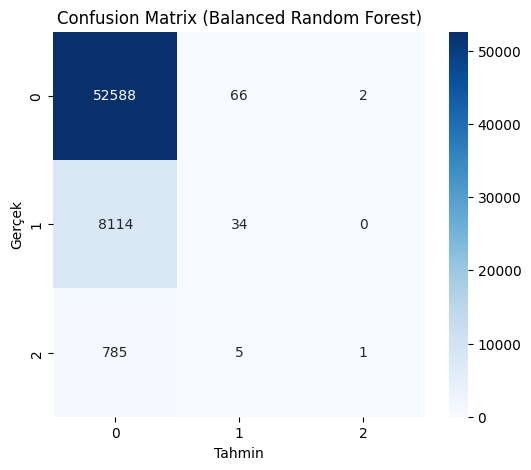

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_bal)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Balanced Random Forest)")
plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.show()

In [12]:
# Örneklem - Random Undersampling (Class-wise Undersampling)

In [13]:
train_df = pd.concat([X_train, y_train], axis=1)

In [14]:
train_df["Severity_num"].value_counts()

Severity_num
0    210624
1     32592
2      3162
Name: count, dtype: int64

In [15]:
n_samples = 3162

balanced_train = (
    train_df
    .groupby("Severity_num")
    .sample(n=n_samples, random_state=42)
)

In [16]:
X_train_bal = balanced_train.drop("Severity_num", axis=1)
y_train_bal = balanced_train["Severity_num"]

print(y_train_bal.value_counts())

Severity_num
0    3162
1    3162
2    3162
Name: count, dtype: int64


In [17]:
##Model 3: Random Forest with Class Weights

In [18]:
from sklearn.ensemble import RandomForestClassifier

rf_balanced_data = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_balanced_data.fit(X_train_bal, y_train_bal)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [19]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_bal_data = rf_balanced_data.predict(X_test)

print(classification_report(y_test, y_pred_bal_data))

              precision    recall  f1-score   support

           0       0.90      0.53      0.67     52656
           1       0.16      0.31      0.21      8148
           2       0.03      0.61      0.06       791

    accuracy                           0.50     61595
   macro avg       0.36      0.48      0.31     61595
weighted avg       0.79      0.50      0.60     61595



In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_bal_data)

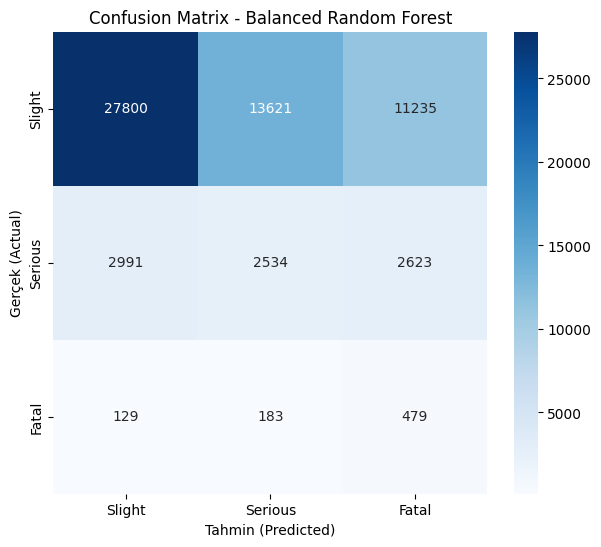

In [21]:
plt.figure(figsize=(7,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Slight", "Serious", "Fatal"],
    yticklabels=["Slight", "Serious", "Fatal"]
)

plt.xlabel("Tahmin (Predicted)")
plt.ylabel("Gerçek (Actual)")
plt.title("Confusion Matrix - Balanced Random Forest")
plt.show()

In [22]:
# Önemli Özellikler

In [23]:
feature_importance = pd.DataFrame({
    "Feature": X_train_bal.columns,
    "Importance": rf_balanced_data.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance", ascending=False
)

feature_importance.head(15)

,Feature,Importance
0,Latitude,0.121734
1,Longitude,0.121131
8,Day,0.098313
10,Hour,0.089572
7,Month,0.068867
9,Weekday,0.042703
3,Number_of_Vehicles,0.036267
2,Number_of_Casualties,0.033419
4,Speed_limit,0.030283
6,Year,0.024605


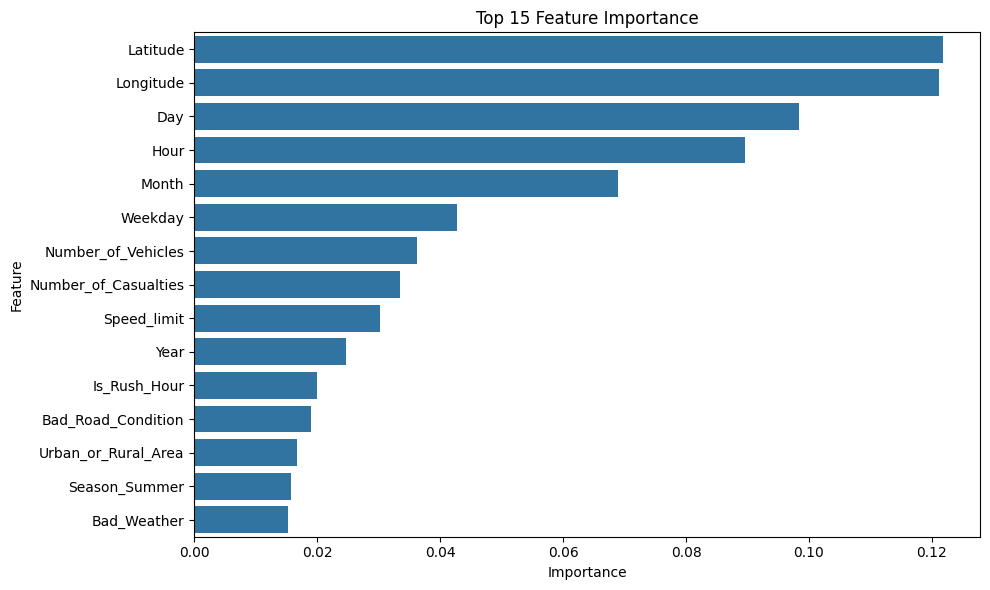

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.head(15)
)

plt.title("Top 15 Feature Importance")
plt.tight_layout()
plt.show()

In [25]:
# en onemli ozellikleri cıkararak tekrar deneme

In [26]:
X_no_geo = X.copy()
X_no_geo = X_no_geo.drop(columns=["Latitude", "Longitude"])

In [27]:
from sklearn.model_selection import train_test_split

X_train_ng, X_test_ng, y_train_ng, y_test_ng = train_test_split(
    X_no_geo,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [28]:
balanced_train_ng = pd.concat([
    pd.concat([
        X_train_ng[y_train_ng == cls],
        y_train_ng[y_train_ng == cls]
    ], axis=1).sample(3162, random_state=42)
    for cls in y_train_ng.unique()
])

X_train_bal_ng = balanced_train_ng.drop("Severity_num", axis=1)
y_train_bal_ng = balanced_train_ng["Severity_num"]

In [29]:
##Model 4- Feature Importance Analysis

In [30]:
from sklearn.ensemble import RandomForestClassifier

rf_no_geo = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_no_geo.fit(X_train_bal_ng, y_train_bal_ng)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [31]:
from sklearn.metrics import classification_report

y_pred_ng = rf_no_geo.predict(X_test_ng)

print(classification_report(y_test_ng, y_pred_ng))

              precision    recall  f1-score   support

           0       0.90      0.50      0.64     52656
           1       0.15      0.32      0.20      8148
           2       0.03      0.53      0.05       791

    accuracy                           0.47     61595
   macro avg       0.36      0.45      0.30     61595
weighted avg       0.79      0.47      0.57     61595



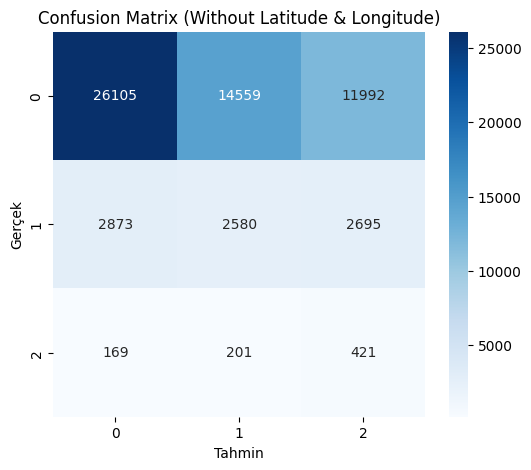

In [32]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_ng, y_pred_ng)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Without Latitude & Longitude)")
plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.show()

In [33]:
##Model 1: Random Forest (Imbalanced Data)

In [34]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))
class_weight_dict

{0: 0.38991757824369494, 1: 2.5198208149239076, 2: 25.97280202403542}

In [35]:
from sklearn.ensemble import RandomForestClassifier

rf_weighted = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight=class_weight_dict
)

rf_weighted.fit(X_train, y_train)

RandomForestClassifier(class_weight={0: 0.38991757824369494,
                                     1: 2.5198208149239076,
                                     2: 25.97280202403542},
                       n_estimators=300, n_jobs=-1, random_state=42)

In [36]:
y_pred_weighted = rf_weighted.predict(X_test)

In [37]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_weighted))

              precision    recall  f1-score   support

           0       0.86      1.00      0.92     52656
           1       0.30      0.00      0.01      8148
           2       0.67      0.00      0.01       791

    accuracy                           0.85     61595
   macro avg       0.61      0.34      0.31     61595
weighted avg       0.78      0.85      0.79     61595



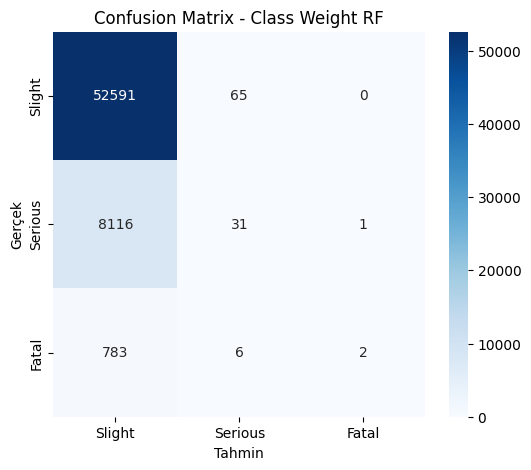

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_weighted)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Slight", "Serious", "Fatal"],
    yticklabels=["Slight", "Serious", "Fatal"]
)
plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.title("Confusion Matrix - Class Weight RF")
plt.show()

In [39]:
print("Train dağılım:\n", y_train.value_counts())
print("Test dağılım:\n", y_test.value_counts())


Train dağılım:
 Severity_num
0    210624
1     32592
2      3162
Name: count, dtype: int64
Test dağılım:
 Severity_num
0    52656
1     8148
2      791
Name: count, dtype: int64


In [40]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

logreg = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),  # sparse değilse with_mean=True de olur
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        solver="lbfgs",
        n_jobs=-1
    ))
])

logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)

print("=== Logistic Regression (argmax/predict) ===")
print(classification_report(y_test, y_pred, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

print("Macro-F1:", f1_score(y_test, y_pred, average="macro"))
print("Weighted-F1:", f1_score(y_test, y_pred, average="weighted"))
print("Accuracy:", accuracy_score(y_test, y_pred))


=== Logistic Regression (argmax/predict) ===
              precision    recall  f1-score   support

           0     0.9025    0.5528    0.6856     52656
           1     0.1730    0.2899    0.2166      8148
           2     0.0294    0.5828    0.0560       791

    accuracy                         0.5184     61595
   macro avg     0.3683    0.4752    0.3194     61595
weighted avg     0.7948    0.5184    0.6155     61595

Confusion matrix:
 [[29107 11137 12412]
 [ 2973  2362  2813]
 [  172   158   461]]
Macro-F1: 0.31940566975586
Weighted-F1: 0.6154903240587496
Accuracy: 0.5183862326487539


In [43]:
print(df.columns.tolist())
print("Severity_3 var mı?", "Severity_3" in df.columns)

['Latitude', 'Longitude', 'Number_of_Casualties', 'Number_of_Vehicles', 'Speed_limit', 'Urban_or_Rural_Area', 'Year', 'Month', 'Day', 'Weekday', 'Hour', 'Is_Rush_Hour', 'Is_Weekend', 'Is_Night', 'Bad_Road_Condition', 'Bad_Weather', 'Day_Monday', 'Day_Saturday', 'Day_Sunday', 'Day_Thursday', 'Day_Tuesday', 'Day_Wednesday', 'Season_Spring', 'Season_Summer', 'Season_Winter', 'Road_Type_One way street', 'Road_Type_Roundabout', 'Road_Type_Single carriageway', 'Road_Type_Slip road', 'Vehicle_Group_Goods', 'Vehicle_Group_Motorcycle', 'Vehicle_Group_Other', 'Vehicle_Group_Public', 'Vehicle_Group_Vulnerable', 'Junction_Control_Grouped_No_Junction', 'Junction_Control_Grouped_Sign_Controlled', 'Junction_Control_Grouped_Unknown', 'Junction_Detail_Grouped_No_Junction', 'Junction_Detail_Grouped_Roundabout', 'Junction_Detail_Grouped_Simple_Junction', 'Severity_num', 'Speed_Category_Medium', 'Speed_Category_High']
Severity_3 var mı? False


In [44]:
X_train.select_dtypes(include=["object"]).columns


Index([], dtype='object')

In [45]:
y_proba = logreg.predict_proba(X_test)

t_fatal = 0.06
t_serious = 0.22

y_pred_thresh = []
for p in y_proba:
    if p[2] > t_fatal:
        y_pred_thresh.append(2)
    elif p[1] > t_serious:
        y_pred_thresh.append(1)
    else:
        y_pred_thresh.append(0)

print("=== Logistic Regression (threshold) ===")
print(classification_report(y_test, y_pred_thresh, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_thresh))


=== Logistic Regression (threshold) ===
              precision    recall  f1-score   support

           0     0.9381    0.0035    0.0069     52656
           1     0.0616    0.0066    0.0120      8148
           2     0.0131    0.9987    0.0258       791

    accuracy                         0.0167     61595
   macro avg     0.3376    0.3363    0.0149     61595
weighted avg     0.8103    0.0167    0.0078     61595

Confusion matrix:
 [[  182   822 51652]
 [   12    54  8082]
 [    0     1   790]]


In [53]:
## xgboost

In [54]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [55]:
xgb_model = XGBClassifier(
    objective="multi:softprob",   # çok sınıflı
    num_class=3,                  # Slight / Serious / Fatal
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

In [56]:
xgb_model.fit(X_train_bal, y_train_bal)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1, num_class=3, ...)

In [57]:
y_pred_xgb = xgb_model.predict(X_test)

In [58]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.90      0.52      0.66     52656
           1       0.16      0.35      0.22      8148
           2       0.03      0.58      0.06       791

    accuracy                           0.50     61595
   macro avg       0.37      0.48      0.31     61595
weighted avg       0.79      0.50      0.59     61595



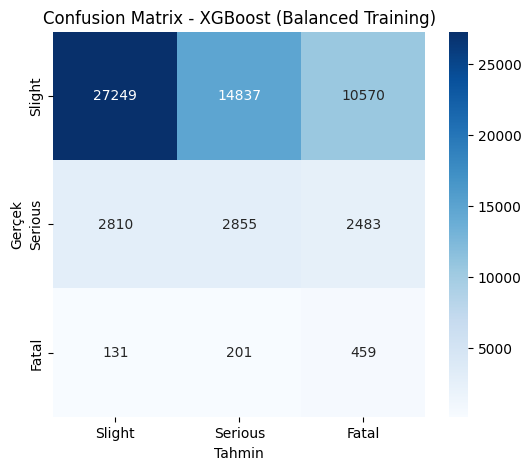

In [59]:
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Slight", "Serious", "Fatal"],
    yticklabels=["Slight", "Serious", "Fatal"]
)
plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.title("Confusion Matrix - XGBoost (Balanced Training)")
plt.show()

In [62]:
# bool sutunları 0-1 cevirme

In [61]:
X_train_lgb = X_train.copy()
X_test_lgb = X_test.copy()

for col in X_train_lgb.columns:
    if X_train_lgb[col].dtype == "bool":
        X_train_lgb[col] = X_train_lgb[col].astype(int)
        X_test_lgb[col] = X_test_lgb[col].astype(int)

In [63]:
X = df.drop("Severity_num", axis=1)
y = df["Severity_num"]

In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [65]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, weights))
print(class_weight_dict)

{0: 0.38991757824369494, 1: 2.5198208149239076, 2: 25.97280202403542}


In [66]:
sample_weight = y_train.map(class_weight_dict)

In [67]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    max_depth=6,
    learning_rate=0.1,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train,
    sample_weight=sample_weight
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None, num_class=3, ...)

In [68]:
y_proba = xgb_model.predict_proba(X_test)
y_pred = y_proba.argmax(axis=1)

In [69]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.63      0.74     52656
           1       0.19      0.43      0.27      8148
           2       0.05      0.43      0.08       791

    accuracy                           0.60     61595
   macro avg       0.38      0.49      0.36     61595
weighted avg       0.80      0.60      0.67     61595



In [70]:
y_pred = []
for probs in y_proba:
    if probs[2] > 0.25:
        y_pred.append(2)
    elif probs[1] > 0.35:
        y_pred.append(1)
    else:
        y_pred.append(0)

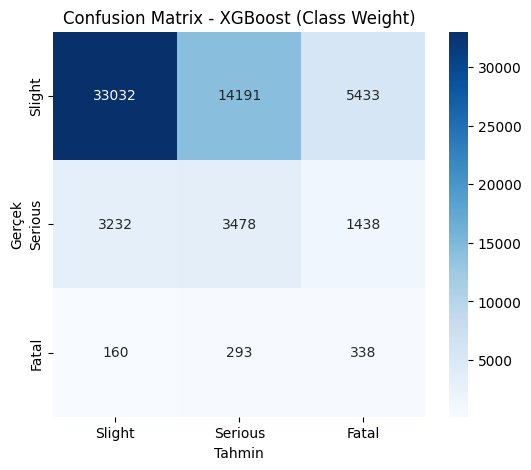

In [71]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

#Tahmin
y_proba = xgb_model.predict_proba(X_test)
y_pred = y_proba.argmax(axis=1)

#Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Slight", "Serious", "Fatal"],
    yticklabels=["Slight", "Serious", "Fatal"]
)

plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.title("Confusion Matrix - XGBoost (Class Weight)")
plt.show()

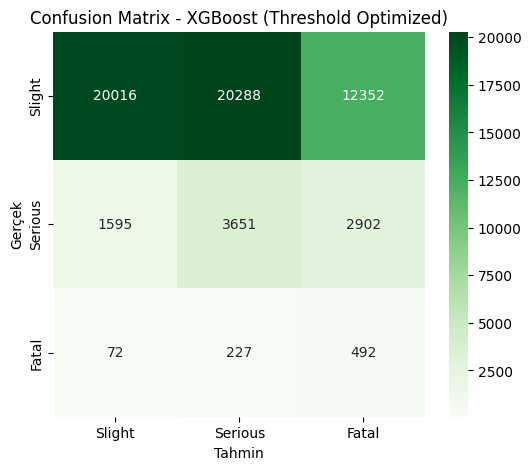

In [72]:
#Threshold'lu tahmin
y_pred_thresh = []

for probs in y_proba:
    if probs[2] > 0.25:        # Fatal
        y_pred_thresh.append(2)
    elif probs[1] > 0.35:      # Serious
        y_pred_thresh.append(1)
    else:
        y_pred_thresh.append(0)

#Confusion matrix
cm_thresh = confusion_matrix(y_test, y_pred_thresh)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_thresh,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Slight", "Serious", "Fatal"],
    yticklabels=["Slight", "Serious", "Fatal"]
)

plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.title("Confusion Matrix - XGBoost (Threshold Optimized)")
plt.show()

In [73]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.05, 0.95, 0.05)

results = []

#Gerçek Fatal = 1, diğerleri = 0
y_true_fatal = (y_test == 2).astype(int)
y_proba_fatal = y_proba[:, 2]

for t in thresholds:
    y_pred_fatal = (y_proba_fatal >= t).astype(int)

    precision = precision_score(y_true_fatal, y_pred_fatal, zero_division=0)
    recall = recall_score(y_true_fatal, y_pred_fatal)
    f1 = f1_score(y_true_fatal, y_pred_fatal)

    results.append({
        "Threshold": round(t, 2),
        "Precision": round(precision, 3),
        "Recall": round(recall, 3),
        "F1": round(f1, 3)
    })

df_thresholds = pd.DataFrame(results)
df_thresholds

,Threshold,Precision,Recall,F1
0,0.05,0.015,0.971,0.029
1,0.10,0.019,0.898,0.037
2,0.15,0.023,0.795,0.044
3,0.20,0.027,0.700,0.051
4,0.25,0.031,0.622,0.060
5,0.30,0.037,0.559,0.070
6,0.35,0.044,0.483,0.080
7,0.40,0.051,0.403,0.091
8,0.45,0.061,0.335,0.104
9,0.50,0.072,0.264,0.114


In [74]:
from sklearn.metrics import f1_score

thresholds = np.arange(0.1, 0.9, 0.1)
results = []

for t_fatal in thresholds:
    for t_serious in thresholds:
        y_pred = []

        for probs in y_proba:
            if probs[2] > t_fatal:
                y_pred.append(2)
            elif probs[1] > t_serious:
                y_pred.append(1)
            else:
                y_pred.append(0)

        macro_f1 = f1_score(y_test, y_pred, average="macro")

        results.append({
            "Fatal_th": t_fatal,
            "Serious_th": t_serious,
            "Macro_F1": macro_f1
        })

pd.DataFrame(results).sort_values("Macro_F1", ascending=False).head()

,Fatal_th,Serious_th,Macro_F1
44,0.6,0.5,0.401986
52,0.7,0.5,0.401062
36,0.5,0.5,0.396617
60,0.8,0.5,0.387160
43,0.6,0.4,0.381748


In [78]:
# XGBoost + Threshold fatal 0.6, serious 0.5

In [75]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

# Seçilen threshold'lar
t_fatal = 0.6
t_serious = 0.5

# Threshold'lu tahmin
y_pred_final = []

for probs in y_proba:
    if probs[2] > t_fatal:
        y_pred_final.append(2)
    elif probs[1] > t_serious:
        y_pred_final.append(1)
    else:
        y_pred_final.append(0)

# === METRİKLER ===
print("===== FINAL MODEL (XGBoost + Threshold) =====\n")

print("Accuracy:", round(accuracy_score(y_test, y_pred_final), 3))
print("Macro F1:", round(f1_score(y_test, y_pred_final, average="macro"), 3))
print("Weighted F1:", round(f1_score(y_test, y_pred_final, average="weighted"), 3))
print("Macro Precision:", round(precision_score(y_test, y_pred_final, average="macro"), 3))
print("Macro Recall:", round(recall_score(y_test, y_pred_final, average="macro"), 3))

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_final))

# === CONFUSION MATRIX ===
cm_final = confusion_matrix(y_test, y_pred_final)
print("\nConfusion Matrix:\n", cm_final)

===== FINAL MODEL (XGBoost + Threshold) =====

Accuracy: 0.779
Macro F1: 0.402
Weighted F1: 0.778
Macro Precision: 0.398
Macro Recall: 0.409

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.87      0.88      0.88     52656
           1       0.22      0.20      0.21      8148
           2       0.10      0.15      0.12       791

    accuracy                           0.78     61595
   macro avg       0.40      0.41      0.40     61595
weighted avg       0.78      0.78      0.78     61595


Confusion Matrix:
 [[46245  5650   761]
 [ 6238  1642   268]
 [  554   121   116]]


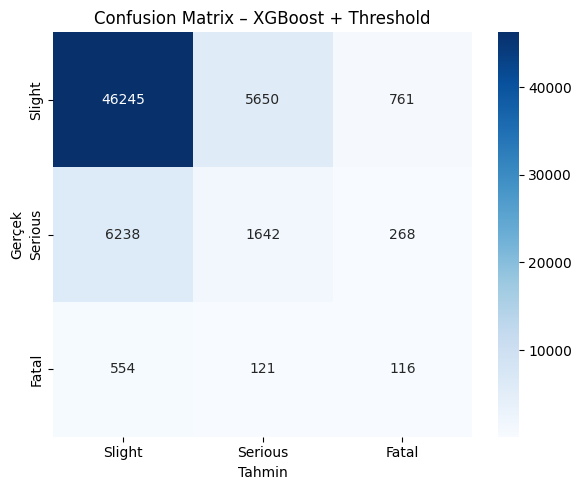

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Slight", "Serious", "Fatal"],
    yticklabels=["Slight", "Serious", "Fatal"]
)

plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.title("Confusion Matrix – XGBoost + Threshold")

plt.tight_layout()
plt.show()


In [81]:
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score

print("FINAL MODEL: XGBoost + Threshold (0.60 / 0.50)\n")

print("Accuracy:", round(accuracy_score(y_test, y_pred_final), 3))
print("Macro F1:", round(f1_score(y_test, y_pred_final, average="macro"), 3))
print("Weighted F1:", round(f1_score(y_test, y_pred_final, average="weighted"), 3))
print("Macro Precision:", round(precision_score(y_test, y_pred_final, average="macro"), 3))
print("Macro Recall:", round(recall_score(y_test, y_pred_final, average="macro"), 3))


FINAL MODEL: XGBoost + Threshold (0.60 / 0.50)

Accuracy: 0.779
Macro F1: 0.402
Weighted F1: 0.778
Macro Precision: 0.398
Macro Recall: 0.409


In [82]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values("Importance", ascending=False)

importance.head(10)


,Feature,Importance
38,Junction_Detail_Grouped_Roundabout,0.069846
13,Is_Night,0.064146
41,Speed_Category_High,0.062027
4,Speed_limit,0.049600
3,Number_of_Vehicles,0.044809
6,Year,0.033930
5,Urban_or_Rural_Area,0.030583
37,Junction_Detail_Grouped_No_Junction,0.030096
2,Number_of_Casualties,0.028520
28,Road_Type_Slip road,0.024115


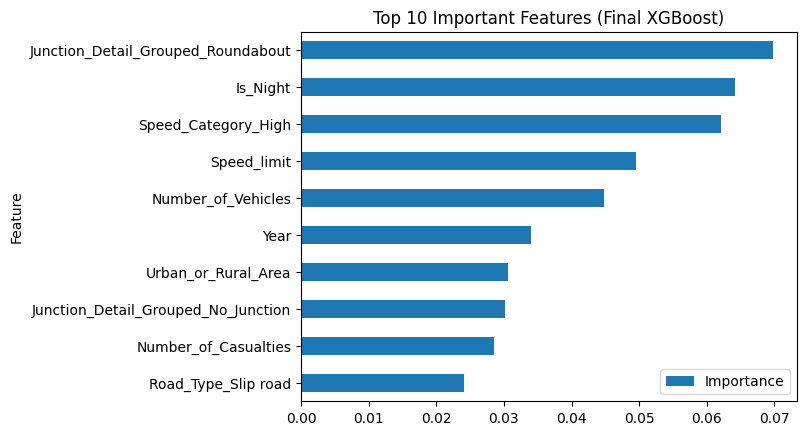

In [83]:
importance.head(10).plot(
    kind="barh", x="Feature", y="Importance",
    title="Top 10 Important Features (Final XGBoost)"
)
plt.gca().invert_yaxis()
plt.show()


In [84]:
import joblib
joblib.dump(xgb_model, "final_xgboost_threshold_060_050.pkl")


['final_xgboost_threshold_060_050.pkl']

In [85]:
joblib.dump(list(X_train.columns), "feature_columns.pkl")

['feature_columns.pkl']